# Implementing a Directed Message Passing Neural Network from scratch

This notebook will walk through the theory implementation of the D-MPNN introduced by "Analyzing Learned Molecular Representations for Property Prediction" Yang et al. 2019.

The DMPNN is a variant of the classic message passing neural network, where the fundamental unit of representation is the directed bond states. This was specifically designed to overcome the tottering problem, where a message from node u to vb
 

We will first implement from scratch in pytorch, before moving to pytorch geometric. 

THe plan:

1. Build a toy graph
2. Get the DMPNN working on the toy graph
3. 

What is the input of our model?

For simplicity, let's imagine we're dealing with a molceular graph.

We represent a molecule as an (2-dimensional for now) undirected graph $G = (V, E)$, where $V = \{v_1, \dots, v_N\}$ is the set of $N$ nodes (atoms) and $E \subseteq V \times V$ is the set of edges (chemical bonds). The structure is encoded by the adjacency matrix $\mathbf{A} \in \{0, 1\}^{N \times N}$. Associated with each node $v_i$ is a feature vector $\mathbf{x}_i \in \mathbb{R}^F$ (e.g., atomic number, hybridization), forming a node feature matrix $\mathbf{X} \in \mathbb{R}^{N \times F}$. Similarly, each edge $(i,j) \in E$ is associated with a bond feature vector $\mathbf{b}_{ij} \in \mathbb{R}^D$ (e.g., bond type or order), forming a bond feature tensor $\mathbf{B} \in \mathbb{R}^{N \times N \times D}$, where $\mathbf{B}_{ij\cdot} = \mathbf{b}_{ij}$ when $(i,j) \in E$ and is zero otherwise. The complete attributed graph is thus represented as $G = (\mathbf{A}, \mathbf{X}, \mathbf{B})$.

In practice, it's much simpler to have $\mathbf{B}\in\mathbb{R}^{E \times D}$, where the rows of this bond feature matrix are indexed by the corresponding edge. For a directed graph, this would become $\mathbf{B}\in\mathbb{R}^{2E \times D}$, where each directed edge corresponds to a row. This way edge u->v can have a different feature vector than v->u. b

In chemprop, the default atom features are atom type, number of bonds, formal charge, etc. . The categorical features are one-hot ecoded, giving a 133 dimensional defult feature vector for each atom. For bonds we have bond type, conjugation, ring membership, stereo. Giving a 14 dimensional feature default vector for each bond. These features are readily available in RDKit. So in our setup, if we imagine a 5-atom molecule as follows, we have $N=5$, $E=5$, $F=144$, $D=14$

So how does the directed message passing neural network work? A standard MPNN takes the input graph and has T message passing steps. Each node gets initialized with a latent representation $h_{v}$. For each message passing step, we first compute the "message" from each node. A standard choice of "message" is simply the mean of the latent representation. Once we have the message from each node, we need to AGGREGATE the incoming m

In [1]:
#build a toy graph
import torch
torch.manual_seed(42)

N = 5 #num atoms
E = 5 #num edges
F = 4 #144 atom feature vec length
D = 3 #14 bond feature vec length
d=6 #hidden dimension
c=F+D #concatenated atom-bond feat vec length

A=torch.tensor([[0,1,0,1,0],
               [1,0,1,0,0],
               [0,1,0,1,0],
               [1,0,1,0,1],
               [0,0,0,1,0]]
               )

#get the edge list from here
edge_index = A.nonzero(as_tuple=False).T 
#edge_index is a 2x2E tensor, where each column represents the index of a non-zero element in A.
#  Row 1=row index, Row 2=col index

#now we need a bond feature matrix (we will generate this randomly for now),
#  where the size of the matrix comes from the edge list
# B=torch.rand(edge_index.shape[1], D)
#construct a random atom and bond feature matrix
# X=torch.rand(N, F)

X = torch.arange(N).unsqueeze(1).expand(N, F) #atom feature matrix
B = torch.arange(2*E).unsqueeze(1).expand(2*E, D) #bond feature matrix


X.shape, B.shape, edge_index.shape

(torch.Size([5, 4]), torch.Size([10, 3]), torch.Size([2, 10]))

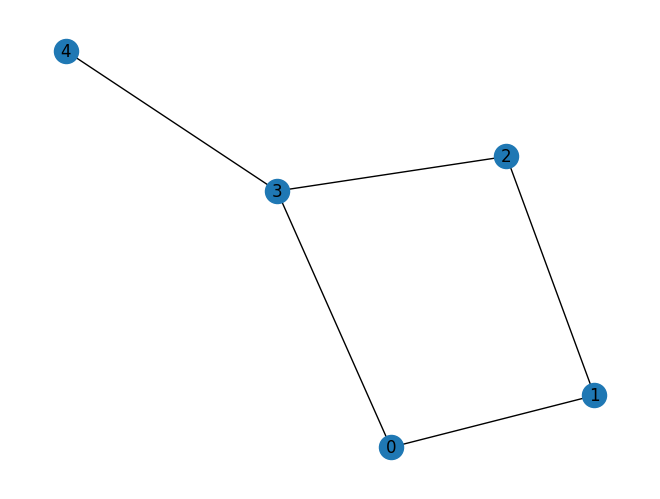

In [2]:
import networkx as nx
#draw network based on A
G = nx.from_numpy_array(A.numpy())
nx.draw(G, with_labels=True)


In [3]:
#so now we have our X, B, and edge list for indexing. For the DMPNN, we are going to need the reverse edge mapping
# for each directed edge i = (u->v), what edge index corresponds to (v->u)? why we need this will be clear later
src, rcv = edge_index

#first we'll make an edge index dict. we zip the two tensors, then enumerate, to create an iterator
#that contains an index, and the tuple of the matching dimension pairs from the two tensors
edge_dict = {(u.item(), v.item()): i for i, (u,v) in enumerate(zip(src, rcv))}


#interate over the zipped tensors, and assign the value (index) of the reverse edge
rev_index = torch.tensor([
edge_dict[(v.item(), u.item())] for u,v in zip(src,rcv)
])
#so now for each colum of edge index, the corresponding entry in rev_index points to the column of the reverse edge

In the DMPNN, we initialize the hidden states with the following:

$$
h_{vu}^{(0)} = \sigma\!\left(W_i [x_v \| b_{vu}]\right)
$$

where:

- $h_{vu}^{(0)}$ is the latent representation of the directed bond from node $v$ to $u$
- $x_v$ is the feature vector of the source node $v$
- $b_{vu}$ is the feature vector of the directed bond
- $W_i \in \mathbb{R}^{d \times c}$, is a learned initializing weight matrix to project representations into $\mathbb{R}^{d}$, where $d$ is the hidden dimension and $c$ is the dimension of the concatenated atom and bond feature vector

In [4]:
#before we can initialize by doing this concatenation, we have B = [10,D], but X = [5,F]
#we need to get the atom feature vector for each source node of each directed edge (expand X to 10xF)
src=edge_index[0]
X_src = X[src] #[10,F]

#start by concatenating bond feat vectors to atom feat vectors
C = torch.cat([X_src,B], dim=1).float()
C.shape #[2E, D+F]

torch.Size([10, 7])

To compute all of the initial hidden states at one time, we can do the following:
$$
H^{(0)} = \sigma\!\left(CW_i^T\right)
$$

Where $H^{(0)}\in\mathbb{R}^{2E \times d}$ now contains the directed bond states. 

In [5]:
#initialize weight matrix via Glorot initilization
W_i = torch.empty(d,c)
W_i = torch.nn.init.xavier_uniform_(W_i)
# W_i = torch.ones(d,c) #temporarily for easier tracking

H_0 = torch.relu(torch.matmul(C,W_i.T))
# H_0 = torch.matmul(C,W_i.T) #ignore relu for now

def initialize_states(C, W_i):
    return torch.relu(torch.matmul(C,W_i.T))

The messages in the DMPNN are comuted by:
$$
m_{vu}^{(t+1)}=\sum_{k \in N(v) \backslash{u}}h_{kv}^{(t)}
$$

In words, the message of a directed bond from $v$ to $u$, is the sum of all latent bond representations of incoming bonds to $v$ EXCLUDING from node $u$. This is the critical distinction of the DMPNN, this exclusion avoids immediate message back passing. 

So to compute the matrix of messages $M$, for for each directed bond, we need to sum all of the incoming bond states, then subtract the bond states of recieving node of that bond. 

In [6]:
edge_index, rev_index

#for each column in edge_index, the corresponding entry in rev_indxe points
#to the column of edge_index that is the reverse

(tensor([[0, 0, 1, 1, 2, 2, 3, 3, 3, 4],
         [1, 3, 0, 2, 1, 3, 0, 2, 4, 3]]),
 tensor([2, 6, 0, 4, 3, 7, 1, 5, 9, 8]))

In [7]:
# #now we compute the "messages", starting with a single bond state
# # for a bond 0,1 get the indices of all bonds going to into 0
# #brute force loop
# M_1=torch.empty(2*E,d)
# #loop over directed edges
# for i in range(2*E):
#     v=src[i]
#     u=rcv[i]
#     m_vu = (rcv==v).nonzero(as_tuple=True)[0] #get indices of edges going into v
#     incoming_states = H_0[m_vu]
#     incoming_sum = incoming_states.sum(dim=0)

#     #get the reverse hidden state
#     reverse_state_index = rev_index[i] 
#     reverse_state = H_0[reverse_state_index]
#     m_vu = incoming_sum - reverse_state

#     #update message tensor
#     M_1[i]=m_vu

# # W_h = torch.empty(d,d)
# # W_h = torch.nn.init.xavier_uniform_(W_h)
# W_h = torch.eye(d,d)

# # H_1 = torch.relu(H_0 + torch.matmul(M_1,W_h.T))
# H_1 = H_0 + torch.matmul(M_1,W_h.T)
                        

Now we need to update the states. The DMPNN uses the following update for a single hidden state:

\begin{equation}
    \mathbf{h}_{vu}^{(t+1)} = 
    \sigma\left(
        \mathbf{h}_{vu}^{(0)} + 
        \mathbf{W}_h \mathbf{m}_{vu}^{(t+1)}
    \right)
\end{equation}

so in matrix form:
$$H^{(1)}=\sigma\left(H^{(0)} + M^{(t+1)}W_h^T\right)$$


In [8]:
def compute_messages(H):
    #brute force loop
    M=torch.empty(2*E,d)
    #loop over directed edges
    for i in range(2*E):
        v=src[i]
        u=rcv[i]
        m_vu = (rcv==v).nonzero(as_tuple=True)[0] #get indices of edges going into v
        incoming_states = H[m_vu]
        incoming_sum = incoming_states.sum(dim=0)

        #get the reverse hidden state
        reverse_state_index = rev_index[i] 
        reverse_state = H[reverse_state_index]
        m_vu = incoming_sum - reverse_state

        #update message tensor
        M[i]=m_vu
    return M

def update(H_0,M):
    return torch.relu(H_0 + torch.matmul(M,W_h.T))

T=3
H=H_0

#init randomizing weights
W_h = torch.empty(d,d)
W_h = torch.nn.init.xavier_uniform_(W_h)

for t in range(T):
    M = compute_messages(H)
    H = update(H_0,M) #skip connection, not residual connection
    print(M.shape, H.shape)


torch.Size([10, 6]) torch.Size([10, 6])
torch.Size([10, 6]) torch.Size([10, 6])
torch.Size([10, 6]) torch.Size([10, 6])


Now, before the pooling step, we need to aggregate back to node-level representations. The DMPNN does this by summing over the incoming bonds, concatenating the original atom feature vector, then applying another linear transformation + relu. 

\begin{equation}
\mathbf{h}_u = \sigma \!\left( \mathbf{W}_a \left[ \mathbf{x}_u \,\|\, \sum_{v \in \mathcal{N}(u)} \mathbf{h}_{vu}^{(T)} \right] \right).
\end{equation}

\begin{equation}
\mathbf{H}_\text{atom-aggd} = \sigma \!\left( \mathbf{R}\mathbf{W}_a^T \right)
\end{equation}

Where the u-th row of $\mathbf{R}$ is the (atom feat | incoming-summed-states) vector of the u-th atom.

In [9]:
R=torch.empty(N,d+F)

W_a = torch.empty(d, d+F) #(the concatenated vector will be of length d (hidden dim) + F (atom feat vec length)), and we want it mapping back to R^d
W_a = torch.nn.init.xavier_uniform_(W_a)
# W_a = torch.eye(d, d+F)

#loop over all atoms in molecule
for u in range(N):
    print("-"*100)
    m_vu = (rcv==u).nonzero(as_tuple=True)[0] #get indices of edges going into u
    print("m_uv:", m_vu.shape, m_vu)
    incoming_states = H[m_vu] #get corresponding bond states
    print("incoming_states: ", incoming_states.shape, incoming_states)
    incoming_sum = incoming_states.sum(dim=0) #sum
    print("incoming_sums: ", incoming_sum.shape, incoming_sum)

    atom_feat = X[u] #get atom feat vec
    print("atom_feat: ", atom_feat, atom_feat.shape)
    x_h = torch.cat([atom_feat, incoming_sum])
    print("x_h: ", x_h.shape, x_h)
    #apply projection
    R[u]=x_h
    print("R: ", R.shape, R)

P = torch.relu(torch.matmul(R, W_a.T))
# P = torch.matmul(R, W_a.T)
print("P: ", P.shape, P)

z_G = torch.sum(P,dim=0)
print("z_G: ", z_G.shape, z_G)

----------------------------------------------------------------------------------------------------
m_uv: torch.Size([2]) tensor([2, 6])
incoming_states:  torch.Size([2, 6]) tensor([[10.4903,  1.0949,  4.4756,  0.0000,  5.4271,  0.8816],
        [15.9691,  3.1894,  5.9160,  0.0000,  0.0000,  0.0000]])
incoming_sums:  torch.Size([6]) tensor([26.4594,  4.2843, 10.3916,  0.0000,  5.4271,  0.8816])
atom_feat:  tensor([0, 0, 0, 0]) torch.Size([4])
x_h:  torch.Size([10]) tensor([ 0.0000,  0.0000,  0.0000,  0.0000, 26.4594,  4.2843, 10.3916,  0.0000,
         5.4271,  0.8816])
R:  torch.Size([5, 10]) tensor([[ 0.0000,  0.0000,  0.0000,  0.0000, 26.4594,  4.2843, 10.3916,  0.0000,
          5.4271,  0.8816],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,

# Lets put everything into modules to build a training loop

In [ ]:
import torch.nn as nn

N = 5 #num atoms
E = 5 #num edges
F = 4 #144 atom feature vec length
D = 3 #14 bond feature vec length
d=6 #hidden dimension
c=F+D #concatenated atom-bond feat vec length

class DMPNNEncoder(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, hidden_dim, num_steps):
        super().__init__()

        self.node_feat_dim = node_feat_dim
        self.edge_feat_dim = edge_feat_dim
        self.hidden_dim = hidden_dim
        self.num_steps = num_steps

        self.W_i = nn.Parameter(torch.empty(hidden_dim, node_feat_dim+edge_feat_dim))
        self.W_h = nn.Parameter(torch.empty(hidden_dim, hidden_dim))
        self.W_a = nn.Parameter(torch.empty(hidden_dim,hidden_dim+node_feat_dim))

        #initialize weight matrices
        torch.nn.init.xavier_uniform_(self.W_i)
        torch.nn.init.xavier_uniform_(self.W_h)
        torch.nn.init.xavier_uniform_(self.W_a)


    def initialize_edge_states(self, X, B, edge_index):
        src, rcv = edge_index
        edge_dict = {(u.item(), v.item()): i for i, (u,v) in enumerate(zip(src, rcv))}
        #iterate over the zipped tensors, and assign the value (index) of the reverse edge
        rev_index = torch.tensor([edge_dict[(v.item(), u.item())] for u,v in zip(src,rcv)])
        src=edge_index[0]
        X_src = X[src] #[10,F]
        C = torch.cat([X_src,B], dim=1).float()
        H_0 = torch.relu(torch.matmul(C, self.W_i.T))
        return H_0, src, rcv, rev_index

    def compute_messages(self, H, d, src, rcv, rev_index):
        #brute force loop
        M=torch.empty(H.shape[0],d)
        #loop over directed edges
        for i in range(2*E):
            v=src[i]
            u=rcv[i]
            m_vu = (rcv==v).nonzero(as_tuple=True)[0] #get indices of edges going into v
            incoming_states = H[m_vu]
            incoming_sum = incoming_states.sum(dim=0)

            #get the reverse hidden state
            reverse_state_index = rev_index[i] 
            reverse_state = H[reverse_state_index]
            m_vu = incoming_sum - reverse_state

            #update message tensor
            M[i]=m_vu
        return M

    def update(self, H_0, M):
        return torch.relu(H_0 + torch.matmul(M, self.W_h.T))


    def aggregate_to_nodes(self, H, X, N, rcv):
        R=torch.empty(N, self.hidden_dim+self.node_feat_dim)
        #loop over all atoms in molecule
        for u in range(N):
            m_vu = (rcv==u).nonzero(as_tuple=True)[0] #get indices of edges going into u
            incoming_states = H[m_vu] #get corresponding bond states
            incoming_sum = incoming_states.sum(dim=0) #sum

            atom_feat = X[u] #get atom feat vec
            x_h = torch.cat([atom_feat, incoming_sum])
            #apply projection
            R[u]=x_h

        P = torch.relu(torch.matmul(R, self.W_a.T))
        return P

    def node_pooling(self, P):
        return torch.sum(P,dim=0)


    def forward(self, X, B, edge_index):
        #initialize hidden states
        H_0, src, rcv, rev_index = self.initialize_edge_states(X, B, edge_index)
        E = X.shape[0]
        H=H_0
        for _ in range(self.num_steps):
            M = self.compute_messages(H, d = self.hidden_dim, src=src, rcv=rcv, rev_index=rev_index, )
            H = self.update(H_0, M) #skip connection, not residual connection

        P = self.aggregate_to_nodes(H, X, N, rcv)
        z_G = self.node_pooling(P)
        return z_G

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size,hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x
    


In [ ]:
N = 5 #num atoms
E = 5 #num edges
F = 4 #144 atom feature vec length
D = 3 #14 bond feature vec length
d=6 #hidden dimension
c=F+D #concatenated atom-bond feat vec length
ffn_hidden_dim=10
output_dim=1
y=2.5

A=torch.tensor([[0,1,0,1,0],
               [1,0,1,0,0],
               [0,1,0,1,0],
               [1,0,1,0,1],
               [0,0,0,1,0]]
               )

#get the edge list from here
edge_index = A.nonzero(as_tuple=False).T 
B=torch.rand(edge_index.shape[1], D)
# construct a random atom and bond feature matrix
X=torch.rand(N, F)


def get_edge_list()

In [ ]:
#lets build a tiny little training loop.
import numpy as np
import torch

torch.manual_seed(42)

#build 3 sample graphs
#carbonyl like
# adjacency matrix
A1 = torch.tensor([
    [0,1,1],
    [1,0,0],
    [1,0,0]
], dtype=torch.float32)

# node features [C, O, N, charge]
X1 = torch.tensor([
    [1., 0., 0., 0.],  # C
    [0., 1., 0., 0.],  # O
    [1., 0., 0., 0.],  # C
])

E1 = torch.tensor([
    [0.,1.],  # double
    [1.,0.],  # single
])

# amine chain
A2 = torch.tensor([
    [0,1,0,0],
    [1,0,1,0],
    [0,1,0,1],
    [0,0,1,0]
], dtype=torch.float32)

X2 = torch.tensor([
    [1., 0., 0., 0.],  # C
    [0., 0., 1., 0.],  # N
    [1., 0., 0., 0.],  # C
    [0., 1., 0., 0.],  # O
])

E2 = torch.tensor([
    [1.,0.],
    [1.,0.],
    [1.,0.],
])

#charged amide-like
A3 = torch.tensor([
    [0,1,1,0],
    [1,0,0,0],
    [1,0,0,1],
    [0,0,1,0]
], dtype=torch.float32)

X3 = torch.tensor([
    [1., 0., 0., 0.],  # C
    [0., 1., 0., 0.],  # O
    [0., 0., 1., 1.],  # N (charged)
    [1., 0., 0., 0.],  # C
])

E3 = torch.tensor([
    [0.,1.],  # double
    [1.,0.],  # single
    [1.,0.],  # single
])

#lets quickly write a function that will take the undirected edge features and convert to B
def make_directed(edges_undir, edge_feat_undir):
    src, rcv, feats = [], [], []
    for i, (u,v) in enumerate(edges_undir):
        src.extend([u,v])
        rcv.extend([v,u])
        feats.append(edge_feat_undir[i])
        feats.append(edge_feat_undir[i])
    edge_index = torch.tensor([src, rcv], dtype=torch.long)
    B = torch.stack(feats.float())
    return edge_index, B

edges1=A1.nonzero(as_tuple=False)[0]
edge_index1, B1 = make_directed(edges1, E1)
edges2=A2.nonzero(as_tuple=False)[0]
edge_index2, B2 = make_directed(edges2, E1)
edges3=A3.nonzero(as_tuple=False)[0]
edge_index3, B3 = make_directed(edges3, E1)

#now the hack here is to put all of these graphs in the same matrices, 
def compute_mse_loss(y, y_hat):
    return torch.sum((y-y_hat)**2)

dmpnn = DMPNNEncoder(F, D, d, 3)
ffn = MLP(d, ffn_hidden_dim, output_dim) #intantiate model

loss = np.inf
thresh=0.001
step=0
lr=10e-2
optimizer = torch.optim.Adam(list(dmpnn.parameters())+list(ffn.parameters()), lr)

while loss>thresh:
    optimizer.zero_grad()
    z = dmpnn(X, B, edge_index)
    y_hat = ffn(z.unsqueeze(0))

    loss = compute_mse_loss(y,y_hat)
    loss.backward()

    optimizer.step()
    step+=1
    if step %1==0:
        print(f"step {step}, prediction: {y_hat.item():.4f}, ", f"loss={loss.item():.4f}", "z_G: ",z)
        # print("W_a: ", dmpnn.W_a, "W_h: ", dmpnn.W_h, "W_i: ", dmpnn.W_i)

    if loss<thresh:
        print(f"converged at step {step}")
    

step 1, prediction: 0.2444,  loss=5.0878 z_G:  tensor([1.6168, 1.4119, 1.1291, 1.6685, 0.0000, 2.1712],
       grad_fn=<SumBackward1>)
step 2, prediction: 0.4013,  loss=4.4047 z_G:  tensor([4.6127, 0.0000, 0.3897, 0.9033, 0.0000, 1.0111],
       grad_fn=<SumBackward1>)
step 3, prediction: 0.6422,  loss=3.4514 z_G:  tensor([5.7189, 0.0000, 0.0000, 0.3531, 0.0000, 0.5203],
       grad_fn=<SumBackward1>)
step 4, prediction: 1.2358,  loss=1.5982 z_G:  tensor([7.1072, 0.0000, 0.0000, 1.4012, 0.0000, 0.2269],
       grad_fn=<SumBackward1>)
step 5, prediction: 2.5912,  loss=0.0083 z_G:  tensor([8.7079, 0.0000, 0.0000, 3.1264, 0.0000, 0.1138],
       grad_fn=<SumBackward1>)
step 6, prediction: 4.3235,  loss=3.3251 z_G:  tensor([10.0702,  0.0000,  0.0000,  4.4131,  0.0000,  0.0266],
       grad_fn=<SumBackward1>)
step 7, prediction: 3.1180,  loss=0.3819 z_G:  tensor([9.1324, 0.0000, 0.0000, 3.2603, 0.0000, 0.0000],
       grad_fn=<SumBackward1>)
step 8, prediction: 2.2098,  loss=0.0842 z_G:  te